# K-Means Clustering — Customer Segmentation

**Simple idea:** Group similar customers together automatically.

Example: A shop wants to know — who are my big spenders? Who are my budget customers?
K-Means finds these groups for us **without** us telling it the answers.

## Step 1 — Import Libraries

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

print('Libraries imported!')

Libraries imported!


## Step 2 — Load the CSV File

In [133]:
df = pd.read_csv('customers.csv')

print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print()
df.head()

Rows: 2000
Columns: 5



,Age,Annual_Income_K,Spending_Score,Purchase_Frequency,Avg_Order_Value
0,56,107,89,18,119
1,69,38,39,15,106
2,46,74,60,12,34
3,32,136,28,15,120
4,60,145,97,13,184


**Column meanings:**
- `Age` — customer age
- `Annual_Income_K` — yearly income in thousands (e.g. 50 means $50,000)
- `Spending_Score` — how much they spend (1 = low, 100 = high)
- `Purchase_Frequency` — how many times they shop per month
- `Avg_Order_Value` — average amount spent per order

## Step 3 — Explore the Data

In [134]:
# Basic statistics
df.describe()

,Age,Annual_Income_K,Spending_Score,Purchase_Frequency,Avg_Order_Value
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,43.805500,82.365000,50.313500,10.087500,186.035000
std,14.929203,39.124572,28.356979,5.554572,94.352785
min,18.000000,15.000000,1.000000,1.000000,20.000000
25%,31.000000,49.000000,26.000000,5.000000,105.000000
50%,44.000000,82.000000,51.000000,10.000000,185.000000
75%,56.000000,117.000000,75.000000,15.000000,266.000000
max,69.000000,149.000000,99.000000,19.000000,349.000000


In [135]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
Age                   0
Annual_Income_K       0
Spending_Score        0
Purchase_Frequency    0
Avg_Order_Value       0
dtype: int64


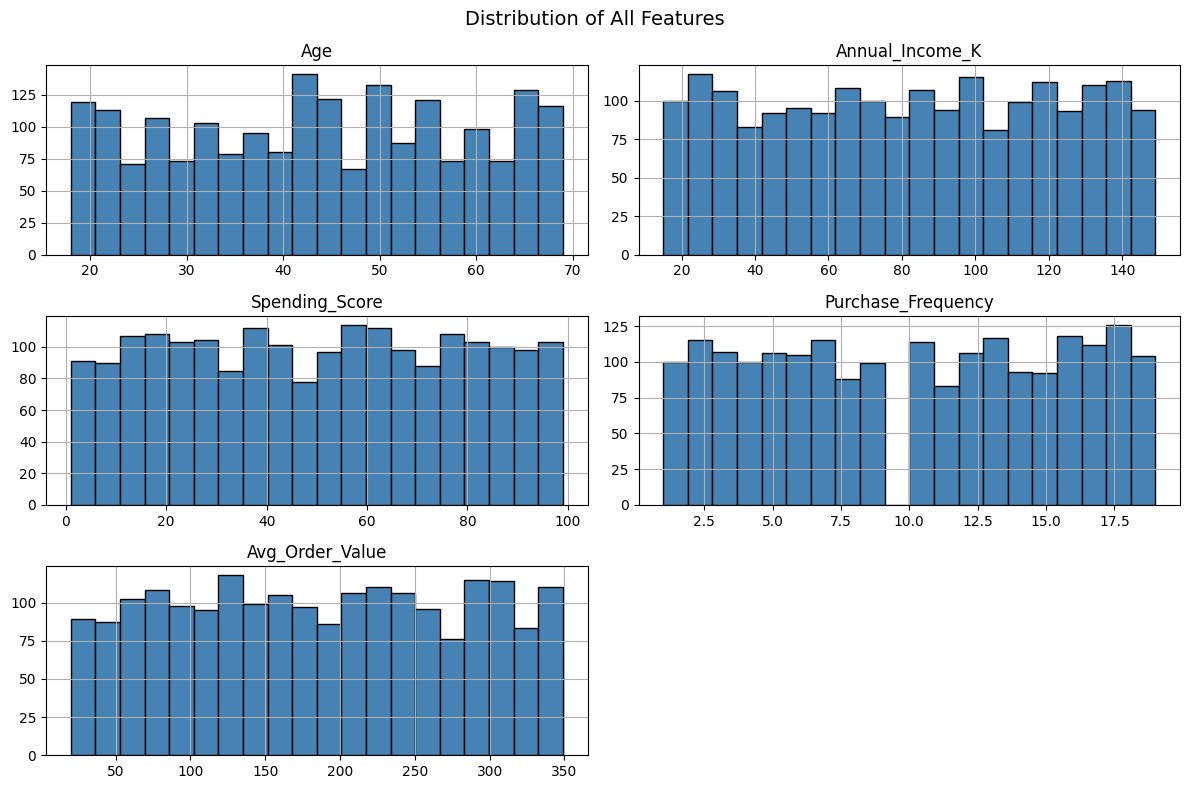

In [136]:
# Plot histograms for all columns
df.hist(figsize=(12, 8), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Distribution of All Features', fontsize=14)
plt.tight_layout()
plt.show()

## Step 4 — Scale the Features

K-Means uses **distance** to group points.

Problem: Income values are like 80, 90... but Spending Score is 1–100 too — but Age is 18–70.
If we don't scale, larger numbers will dominate the distance calculation.

**Solution:** StandardScaler — makes every column have mean = 0 and std = 1.

In [137]:
scaler = StandardScaler()
X = scaler.fit_transform(df)

print('Scaling done!')
print('Shape of scaled data:', X.shape)

Scaling done!
Shape of scaled data: (2000, 5)


In [138]:
km = KMeans(n_clusters=5)
km.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [139]:
# silhouette score
k = [2, 3, 4, 5, 6, 7, 8, 9, 10]
for i in k:
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X)
    score = silhouette_score(X, km.labels_)
    print(f'For k={i}, Silhouette Score: {score:.4f}')

For k=2, Silhouette Score: 0.1503
For k=3, Silhouette Score: 0.1394
For k=4, Silhouette Score: 0.1497
For k=5, Silhouette Score: 0.1541
For k=6, Silhouette Score: 0.1586
For k=7, Silhouette Score: 0.1624
For k=8, Silhouette Score: 0.1669
For k=9, Silhouette Score: 0.1728
For k=10, Silhouette Score: 0.1768


## Step 5 — Find the Best Number of Clusters (Elbow Method)

We don't know how many groups (K) to use.

**Elbow Method:** Try K = 1, 2, 3 ... 10 and measure the error (called **inertia**).
Plot it — the point where the line bends like an "elbow" is the best K.

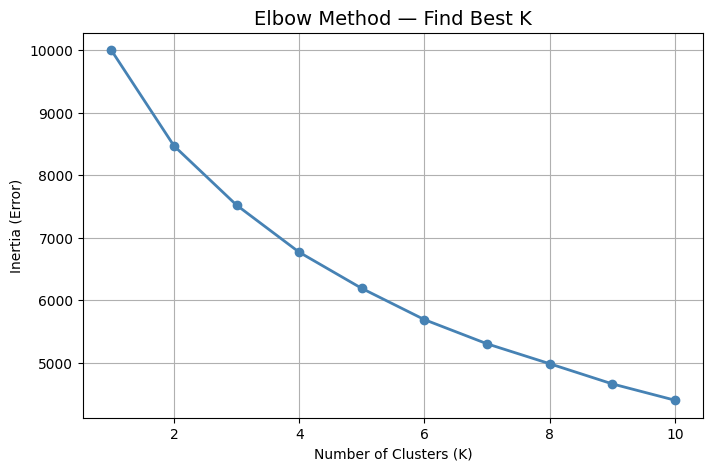

Look for the "elbow" bend in the graph — that is the best K!


In [140]:
inertia_list = [] # empty llist

for k in range(1, 11): # loop  1 ---> 10
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia_list.append(model.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_list, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Find Best K', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Error)')
plt.grid(True)
plt.show()

print('Look for the "elbow" bend in the graph — that is the best K!')